# Introduction
This notebook intends to understand the data in the birdCLEF_2025 dataset and create some simple classifier models for recognizing species by their sound.

In [31]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from IPython.display import Audio
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
import time
from tqdm import tqdm
from sklearn.utils import resample
from matplotlib.colors import ListedColormap
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize


In [32]:
# Load data

INPUT_PATH = os.path.join('birdclef-2025')
TRAIN_AUDIO_PATH = os.path.join(INPUT_PATH, 'train_audio')
TEST_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'test_soundscapes')
TRAIN_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'train_soundscapes')

# Load data
taxonomy = pd.read_csv(os.path.join(INPUT_PATH, 'taxonomy.csv'))
train_meta = pd.read_csv(os.path.join(INPUT_PATH, 'train.csv'))
# recording_locations = pd.read_csv(os.path.join(INPUT_PATH, 'recordming_location.txt'))

## Understanding our data

In [33]:
print(train_meta.dtypes)
train_meta

primary_label        object
secondary_labels     object
type                 object
filename             object
collection           object
rating              float64
url                  object
latitude            float64
longitude           float64
scientific_name      object
common_name          object
author               object
license              object
dtype: object


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28559,ywcpar,[''],[''],ywcpar/iNat77392.ogg,iNat,0.0,https://static.inaturalist.org/sounds/77392.m4a,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,Yennifer Alfaro,cc-by-nc 4.0
28560,ywcpar,[''],[''],ywcpar/iNat78624.ogg,iNat,0.0,https://static.inaturalist.org/sounds/78624.wav,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,Evan Centanni,cc-by-nc-sa 4.0
28561,ywcpar,[''],[''],ywcpar/iNat789234.ogg,iNat,0.0,https://static.inaturalist.org/sounds/789234.wav,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,Henrry,cc-by 4.0
28562,ywcpar,[''],[''],ywcpar/iNat819873.ogg,iNat,0.0,https://static.inaturalist.org/sounds/819873.mp3,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,Alejandro Luy,cc-by-nc 4.0


In [34]:
print(taxonomy.dtypes)
taxonomy # we see that taxonomy allow us to match 'primarry_lables' of train.csv to the species

primary_label      object
inat_taxon_id       int64
scientific_name    object
common_name        object
class_name         object
dtype: object


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1139490,1139490,Ragoniella pulchella,Ragoniella pulchella,Insecta
1,1192948,1192948,Oxyprora surinamensis,Oxyprora surinamensis,Insecta
2,1194042,1194042,Copiphora colombiae,Copiphora colombiae,Insecta
3,126247,126247,Leptodactylus insularum,Spotted Foam-nest Frog,Amphibia
4,1346504,1346504,Neoconocephalus brachypterus,Neoconocephalus brachypterus,Insecta
...,...,...,...,...,...
201,yehcar1,1432779,Milvago chimachima,Yellow-headed Caracara,Aves
202,yelori1,9352,Icterus nigrogularis,Yellow Oriole,Aves
203,yeofly1,16567,Tolmomyias sulphurescens,Yellow-olive Flycatcher,Aves
204,yercac1,10359,Cacicus cela,Yellow-rumped Cacique,Aves


### Preprocessing

In [35]:
# check for duplicate rows
print(f"number of duplicate rows: {train_meta.duplicated().sum()}")

# check if secondary_label and type are empty
print("secondary_labels is empty: " + str((train_meta['secondary_labels'] == '[\'\']').all()))
print("type is empty: " + str((train_meta['type'] == "[\'\']").all()))

# check for NaN values
print(f'number of na values by column \n{train_meta.isna().sum()}')

# remove samples with unavailable locations
train_meta.dropna(inplace=True)

# remove irrelevant columns 
train_meta.drop(['collection', 'author', 'license', 'common_name', 'scientific_name', 'url', 'secondary_labels', 'type'], axis=1, inplace=True)

# link the filenames to our dataset and turn secondary_labels and columns to lists
def preprocess_train_meta(df):
    # df['secondary_labels'] = df['secondary_labels'].apply(lambda x: re.findall(r"'(\w+)'", x))
    # df['type'] = df['type'].apply(lambda x: re.findall(r"'(\w+)'", x))
    df['file_path'] = df.apply(lambda row: os.path.join(TRAIN_AUDIO_PATH, row['filename']), axis=1)
    return df

train_meta = preprocess_train_meta(train_meta)

# Merge class_name from taxonomy into train_meta using primary_label as key
train_meta = train_meta.merge(taxonomy[['primary_label', 'class_name']], on='primary_label', how='left')

train_meta

number of duplicate rows: 0
secondary_labels is empty: False
type is empty: False
number of na values by column 
primary_label         0
secondary_labels      0
type                  0
filename              0
collection            0
rating                0
url                   0
latitude            809
longitude           809
scientific_name       0
common_name           0
author                0
license               0
dtype: int64


,primary_label,filename,rating,latitude,longitude,file_path,class_name
0,1139490,1139490/CSA36385.ogg,0.0,7.3206,-73.7128,birdclef-2025/train_audio/1139490/CSA36385.ogg,Insecta
1,1139490,1139490/CSA36389.ogg,0.0,7.3206,-73.7128,birdclef-2025/train_audio/1139490/CSA36389.ogg,Insecta
2,1192948,1192948/CSA36358.ogg,0.0,7.3791,-73.7313,birdclef-2025/train_audio/1192948/CSA36358.ogg,Insecta
3,1192948,1192948/CSA36366.ogg,0.0,7.2800,-73.8582,birdclef-2025/train_audio/1192948/CSA36366.ogg,Insecta
4,1192948,1192948/CSA36373.ogg,0.0,7.3791,-73.7313,birdclef-2025/train_audio/1192948/CSA36373.ogg,Insecta
...,...,...,...,...,...,...,...
27750,ywcpar,ywcpar/iNat77392.ogg,0.0,7.6921,-80.3379,birdclef-2025/train_audio/ywcpar/iNat77392.ogg,Aves
27751,ywcpar,ywcpar/iNat78624.ogg,0.0,8.9918,-79.4877,birdclef-2025/train_audio/ywcpar/iNat78624.ogg,Aves
27752,ywcpar,ywcpar/iNat789234.ogg,0.0,9.2316,-70.2041,birdclef-2025/train_audio/ywcpar/iNat789234.ogg,Aves
27753,ywcpar,ywcpar/iNat819873.ogg,0.0,10.5838,-66.8545,birdclef-2025/train_audio/ywcpar/iNat819873.ogg,Aves


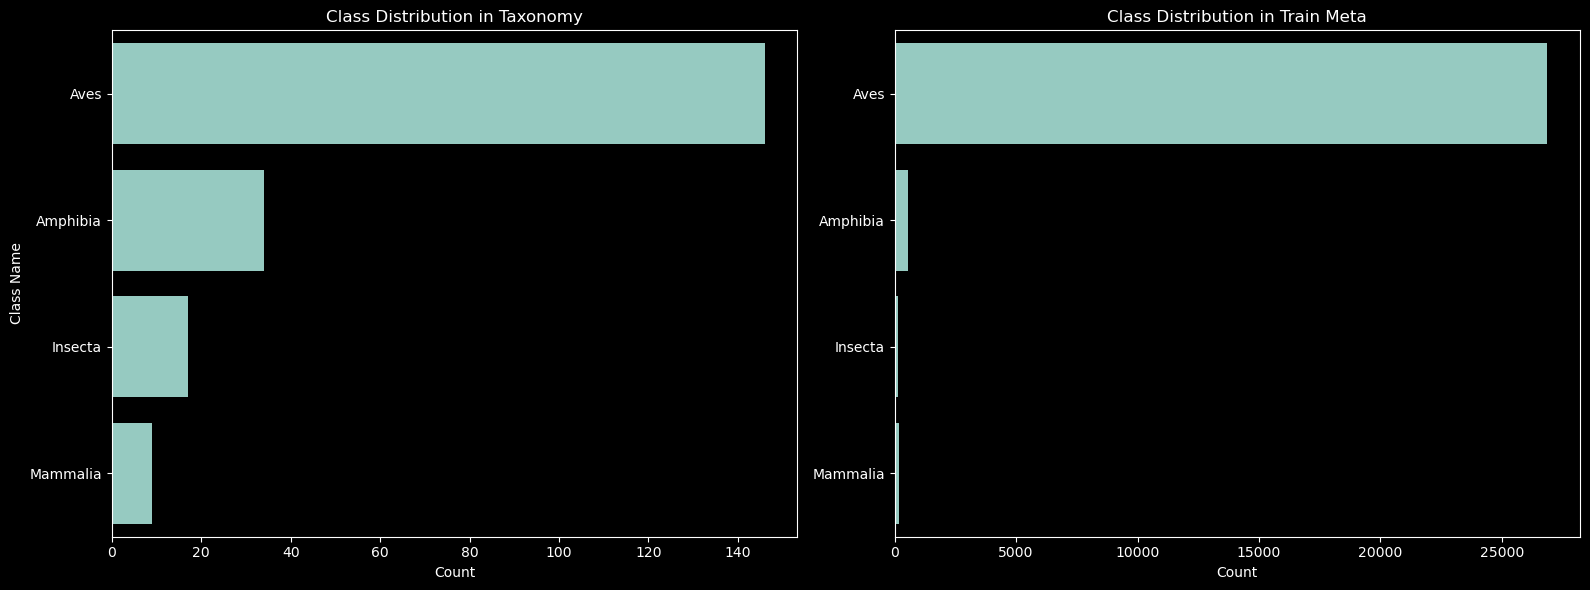

In [36]:
# Create side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot for taxonomy
sns.countplot(
    data=taxonomy,
    y='class_name',
    order=taxonomy['class_name'].value_counts().index,
    ax=axs[0]
)
axs[0].set_title('Class Distribution in Taxonomy')
axs[0].set_xlabel('Count')
axs[0].set_ylabel('Class Name')

# Plot for train_meta
sns.countplot(
    data=train_meta,
    y='class_name',
    order=taxonomy['class_name'].value_counts().index,  # Same order for consistency
    ax=axs[1]
)
axs[1].set_title('Class Distribution in Train Meta')
axs[1].set_xlabel('Count')
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

We can see that there is a large class imbalance in the dataset. 

count
2     15
5      7
6      6
4      4
3      4
      ..
19     1
20     1
21     1
10     1
8      1
Name: count, Length: 135, dtype: int64 

Unique primary labels in train_meta: 135


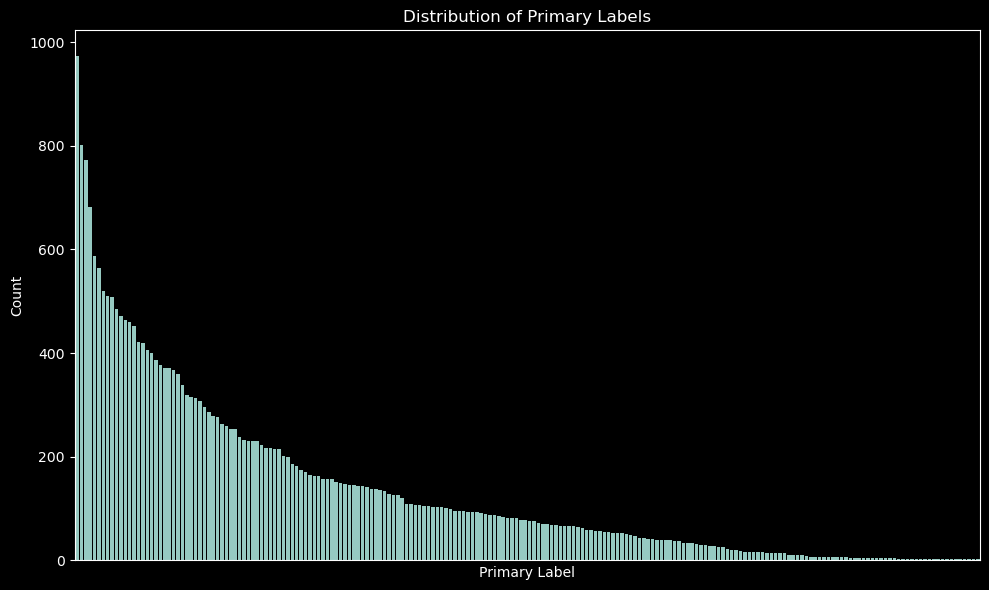

In [37]:
label_distribution = train_meta['primary_label'].value_counts()

print(label_distribution.value_counts(), "\n")
print(f"Unique primary labels in train_meta: {label_distribution.nunique()}")\

plt.figure(figsize=(10, 6))
sns.barplot(x=label_distribution.index, y=label_distribution.values)
plt.title('Distribution of Primary Labels')
plt.xlabel('Primary Label')
plt.ylabel('Count')
plt.xticks([])
plt.tight_layout()
plt.show()

As expected, the imbalance is also significant for primary labels. 

We filter out recordings with low quality based on their ratings.

In [38]:
train_meta = train_meta[train_meta['rating'] >= 2]
print(train_meta.shape[0])

19508




Another problem is the large computational time for processing many audio files, so, we first decide to filter audio files based on their duration.

Measuring durations:   0%|          | 0/200 [00:00<?, ?it/s]

Measuring durations: 100%|██████████| 200/200 [00:06<00:00, 29.51it/s]


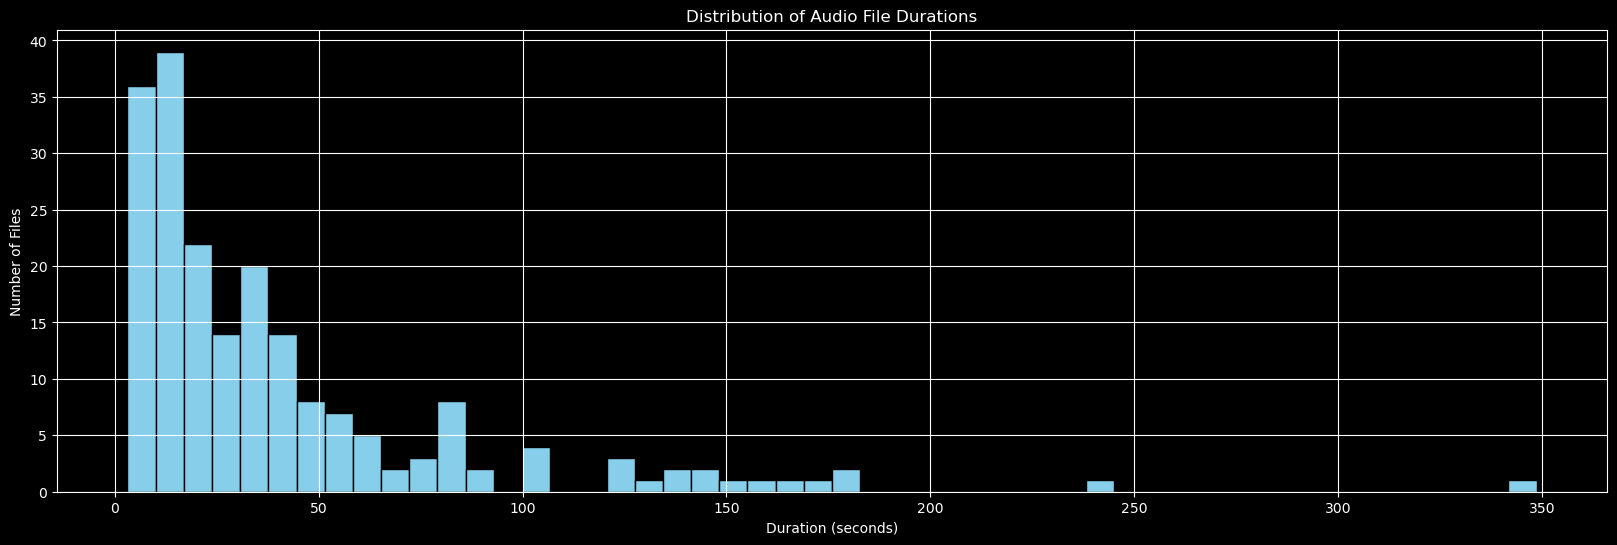

In [39]:
# sample
sampled_meta = train_meta.sample(n=200, random_state=42)

# function to get a file's duration
def get_duration(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)  # Correct variable
        duration = librosa.get_duration(y=y, sr=sr)
        return duration
    except Exception as e:
        print(f"Could not load {file_path}: {e}")
        return None  # Use None to signify failure

# Collect durations
durations = []
for path in tqdm(sampled_meta['file_path'], desc="Measuring durations"):
    durations.append(get_duration(path))

# Plot the distribution
plt.figure(figsize=(20, 6))
plt.hist(durations, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Audio File Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.grid(True)
plt.show()

We decide to keep files shorter than 20 seconds long.

Size before filtering: 19508
Size after filtering: 11037



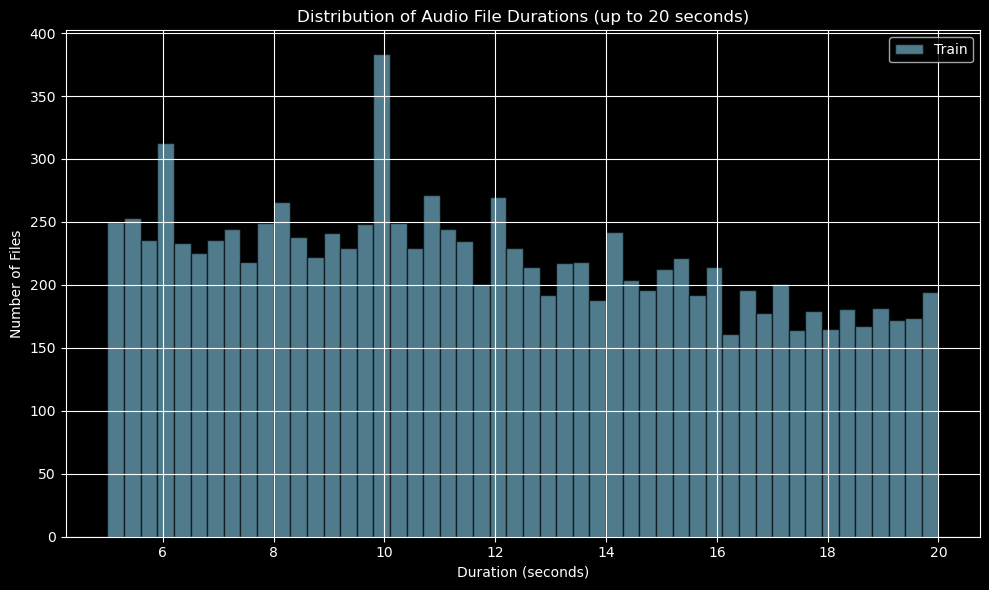

In [40]:
tqdm.pandas()

def filter_audio_duration(df, lower_bound, upper_bound):
    df['duration'] = df['file_path'].progress_apply(get_duration)
    df_filtered = df[
        (df['duration'] >= lower_bound) & (df['duration'] <= upper_bound)
    ].copy()
    return df_filtered

print(f"Size before filtering: {len(train_meta)}")

if not os.path.exists('filtered_duration.csv'):
    train_meta_filtered = filter_audio_duration(train_meta, 0, 20)
    train_meta_filtered.to_csv('filtered_duration.csv', index=False)
else:
    train_meta_filtered = pd.read_csv('filtered_duration.csv')
print(f"Size after filtering: {len(train_meta_filtered)}\n")


# Plot the filtered durations
plt.figure(figsize=(10, 6))
plt.hist(train_meta_filtered['duration'], bins=50, alpha=0.6, label='Train', color='skyblue', edgecolor='black')
# plt.hist(test_df_filtered['duration'], bins=50, alpha=0.6, label='Test', color='salmon', edgecolor='black')
# plt.hist(val_df_filtered['duration'], bins=50, alpha=0.6, label='Validation', color='yellow', edgecolor='black')
plt.title("Distribution of Audio File Durations (up to 20 seconds)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Unique primary labels in train_meta_filtered: 
primary_label
grekis     468
trokin     317
compau     306
soulap1    274
bbwduc     237
          ... 
1194042      1
134933       1
21116        1
50186        1
bubcur1      1
Name: count, Length: 190, dtype: int64

Unique primary labels in train_meta_filtered: 100


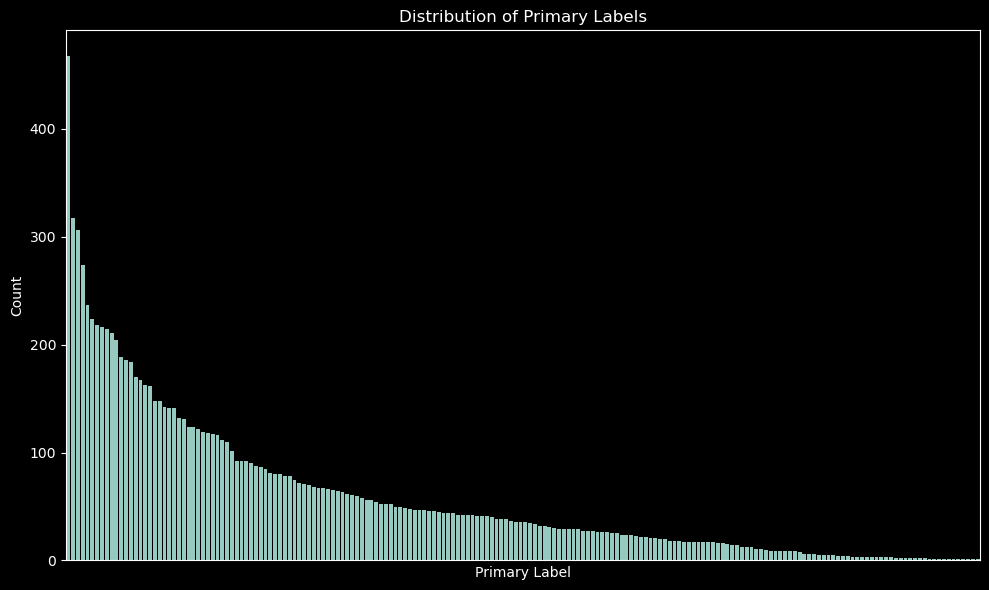

In [41]:
label_distribution = train_meta_filtered['primary_label'].value_counts()

# print(label_distribution.value_counts(), "\n")
print(f"Unique primary labels in train_meta_filtered: \n{label_distribution}\n")
print(f"Unique primary labels in train_meta_filtered: {label_distribution.nunique()}")

plt.figure(figsize=(10, 6))
sns.barplot(x=label_distribution.index, y=label_distribution.values)
plt.title('Distribution of Primary Labels')
plt.xlabel('Primary Label')
plt.ylabel('Count')
plt.xticks([])
plt.tight_layout()
plt.show()

We will also filter out species with 10 or less recordings, thus avoiding outliers and enabling stratifying.

In [42]:
label_counts = train_meta_filtered['primary_label'].value_counts()
valid_labels = label_counts[label_counts >= 10].index
train_meta_filtered = train_meta_filtered[train_meta_filtered['primary_label'].isin(valid_labels)].reset_index(drop=True).copy()

label_distribution = train_meta_filtered['primary_label'].value_counts()
print(f"Unique primary labels in train_meta_filtered: {label_distribution.nunique()}")
print(f"Recordings: {train_meta_filtered.shape[0]}")

Unique primary labels in train_meta_filtered: 92
Recordings: 10873


At this point we would like to split the data into a training set, test set and validation set, while stratifying, so that proportions are not lost for testing. However, since we've decided to use the sound files and locations for classifying, we need to aggregate the data first.

### Feature extraction

Based on the EDA and additional research, we decided to use Mel-Frequency Cepstral Coefficients (MFCCs) to train our model.

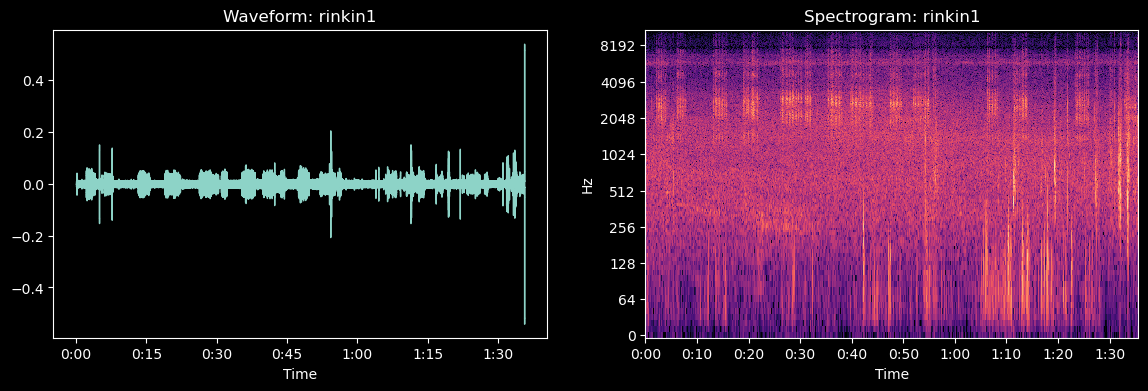

In [43]:
# lets explore an audio file
audio_examples = train_meta.sample(1)
file_path = audio_examples['file_path'].tolist()[0]
title = audio_examples['primary_label'].tolist()[0]


Audio(file_path)
y, sr = librosa.load(file_path)
# Plot waveform
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform: " + title )

# Plot spectrogram
plt.subplot(1, 2, 2)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.title(f'Spectrogram: {title}')

plt.show()

In [44]:
# Feature Extraction (Simple MFCC)
def extract_mfcc(file_path, sr=22050, n_mfcc=20):
    """Extracts MFCC features from an audio file."""
    try:
        y, sr = librosa.load(file_path, sr=sr)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_processed = np.mean(mfccs.T, axis=0)  # Average across time
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
    return mfccs_processed

# Example MFCC extraction
example_file = train_meta['file_path'].iloc[0]
mfccs = extract_mfcc(example_file)
print("\nMFCC Features Example:\n", mfccs)


MFCC Features Example:
 [-112.98774     -15.514137    -36.073566    -79.887985      2.8432212
  -21.126192     -4.373921      3.8334134   -40.57184       3.1096613
   -4.771042    -26.274094     -2.1829772    -0.65615106   -2.5428727
  -17.601885     -5.2439723    -2.454687    -13.67258      -2.1525416 ]


We extract the MFCC features, as well as the locations and aggregate them.

In [45]:
import os

# Feature Extraction (Simple MFCC)
def extract_mfcc(file_path, sr=22050, n_mfcc=20):
    """Extracts MFCC features from an audio file."""
    try:
        y, sr = librosa.load(file_path, sr=sr)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_processed = np.mean(mfccs.T, axis=0)  # Average across time
        return mfccs_processed
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
    

if not os.path.exists('all_features.npy'):
    # Extract MFCC features
    features = []
    labels = []
    valid_indices = []

    for idx, row in tqdm(train_meta_filtered.iterrows(), total=len(train_meta_filtered), desc="Extracting train MFCCs"):
        mfccs = extract_mfcc(row['file_path'])
        if mfccs is not None:
            features.append(mfccs)
            labels.append(row['primary_label'])
            valid_indices.append(idx)

    mfccs = np.array(features)

    # Extract locations
    locations = train_meta_filtered.loc[valid_indices, ['longitude', 'latitude']].values
    # Concatenate audio and location features
    all_features = np.hstack([mfccs, locations])



    np.save('mfccs.npy', mfccs)
    np.save('locations.npy', np.array(locations))
    np.save('labels.npy', np.array(labels))
    np.save('all_features.npy', np.array(all_features))
else:
    print("all_features.npy already exists. Skipping feature extraction.")
    # Load features
    all_features = np.load('all_features.npy')
    mfccs = np.load('mfccs.npy')
    locations = np.load('locations.npy')
    labels = np.load('labels.npy')


all_features.npy already exists. Skipping feature extraction.


In [46]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

np.save('labels_encoded.npy', np.array(labels_encoded))

In [47]:
# Feature Scaling
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)
mfccs_scaled = scaler.fit_transform(mfccs)

np.save('all_features_scaled.npy', all_features_scaled)
np.save('mfccs_scaled.npy', mfccs_scaled)

In [48]:
print(len(all_features_scaled))
print(len(mfccs_scaled))
print(len(labels_encoded))

10873
10873
10873


### Splitting and sampling functions

In [49]:
X = np.load('mfccs_scaled.npy')
X_all = np.load('all_features_scaled.npy')
y = np.load('labels_encoded.npy')

In [50]:
def split(X, y, test_size=0.2, validation=False, val_size=0.25):
    # train/test split
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # test/val split
    if validation:
        X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=val_size, random_state=42, stratify=y_train_full)
        return X_train, y_train, X_test, y_test, X_val, y_val
    else:
        return X_train_full, y_train_full, X_test, y_test, None, None


In [51]:
def sample(X, y, sample_fraction=0.5, random_state=42):
    X_sample, _, y_sample, _ = train_test_split(
        X, y,
        train_size=sample_fraction,
        stratify=y,
        random_state=random_state
    )
    return X_sample, y_sample

In [52]:
def remove_classes_under(X, y, min_instances=20):
    class_counts = Counter(y)
    
    # Get valid classes
    valid_classes = {cls for cls, count in class_counts.items() if count >= min_instances}
    
    # Create mask for valid samples
    mask = np.array([label in valid_classes for label in y])
    
    # Filter X and y
    X_filtered = X[mask]
    y_filtered = y[mask]

    return X_filtered, y_filtered

## Training Models
- SVM
- Naive Bayes
- KNN
- Random Forest
- 

In [53]:
def evaluate_model(model, X_test, y_test, model_name="Model", class_labels=None):
    """
    Evaluates a classifier with metrics and plots.

    This function handles both models that can and cannot produce probability scores.

    Parameters:
    - model: The trained classifier object.
    - X_test (array-like): The test feature data.
    - y_test (array-like): The true test labels.
    - model_name (str): The name of the model for titles and printouts.
    - class_labels (list of str, optional): The original string names of the classes
      for more readable plot labels. If None, integer labels are used.
    """
    print(f"\n{'='*20} Evaluating {model_name} {'='*20}")

    # --- 1. Basic Metrics from Predictions ---
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted Precision: {prec:.4f}")
    print(f"Weighted Recall: {rec:.4f}")
    print(f"Weighted F1-score: {f1:.4f}\n")

    # --- 2. Prepare figure with 3 horizontal subplots ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_labels if class_labels is not None else np.unique(y_test),
                yticklabels=class_labels if class_labels is not None else np.unique(y_test))
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    # --- 3. Probability-based Curves (ROC and Precision-Recall) ---
    # Check if the model has the 'predict_proba' method
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        classes = np.unique(y_test)
        y_test_bin = label_binarize(y_test, classes=classes)

        # ROC
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='deeppink', linestyle=':', linewidth=2,
                     label=f'Micro-average ROC (AUC = {roc_auc:.2f})')
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title("ROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend(loc='lower right')
        axes[1].grid(True)

        # Precision-Recall
        precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
        axes[2].plot(recall, precision, color='navy', linestyle=':', linewidth=2)
        axes[2].set_title("Precision-Recall Curve")
        axes[2].set_xlabel("Recall")
        axes[2].set_ylabel("Precision")
        axes[2].grid(True)

    else:
        axes[1].text(0.5, 0.5, 'No probability output\nROC skipped',
                     ha='center', va='center', fontsize=12)
        axes[2].text(0.5, 0.5, 'No probability output\nPR skipped',
                     ha='center', va='center', fontsize=12)
        axes[1].axis('off')
        axes[2].axis('off')

    fig.suptitle(f"{model_name} Evaluation", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [54]:
    # Sample and clean
X_sampled, y_sampled = sample(X, y, 0.1)
X_sampled, y_sampled = remove_classes_under(X_sampled, y_sampled, min_instances=20)

### SVM

--- Training XGBoost Model ---
Using a sample of 289 instances with 11 classes.
Applying SMOTE to the training data...

==================== Evaluating Support Vector Machine (linear) ====================
Accuracy: 0.1379
Weighted Precision: 0.1206
Weighted Recall: 0.1379
Weighted F1-score: 0.1243



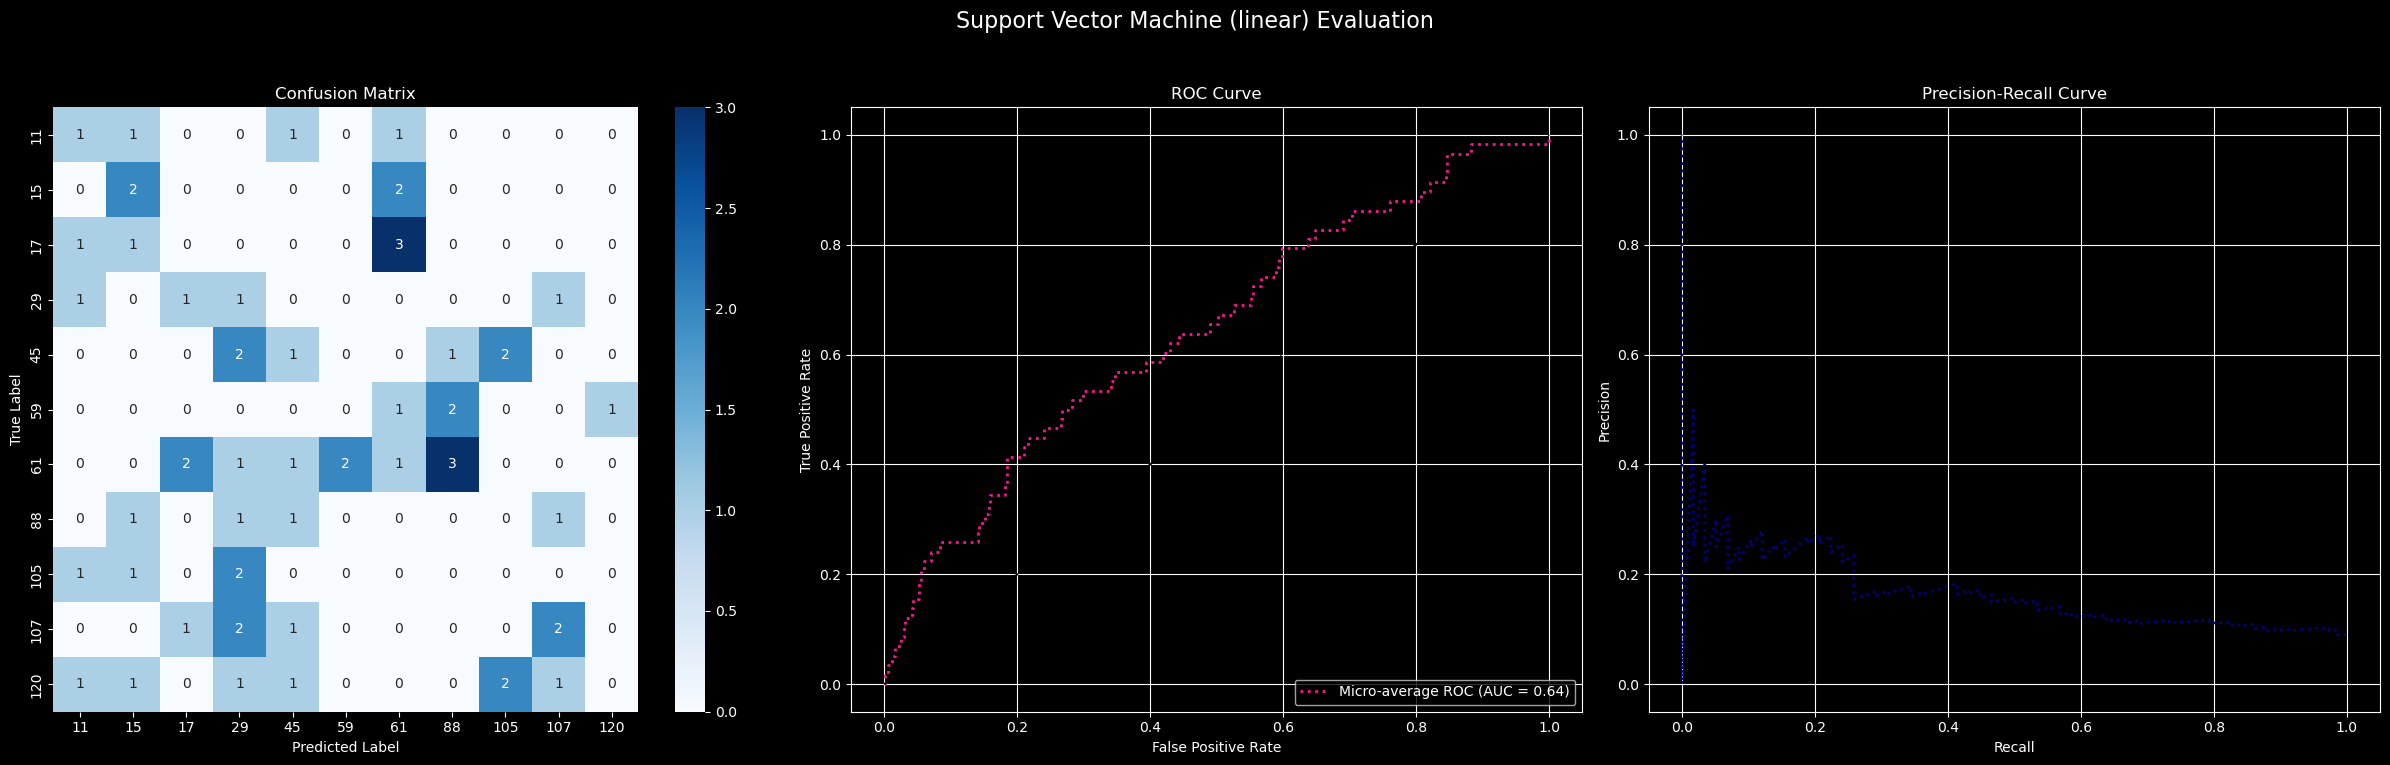


==================== Evaluating Support Vector Machine (poly) ====================
Accuracy: 0.1724
Weighted Precision: 0.1930
Weighted Recall: 0.1724
Weighted F1-score: 0.1786



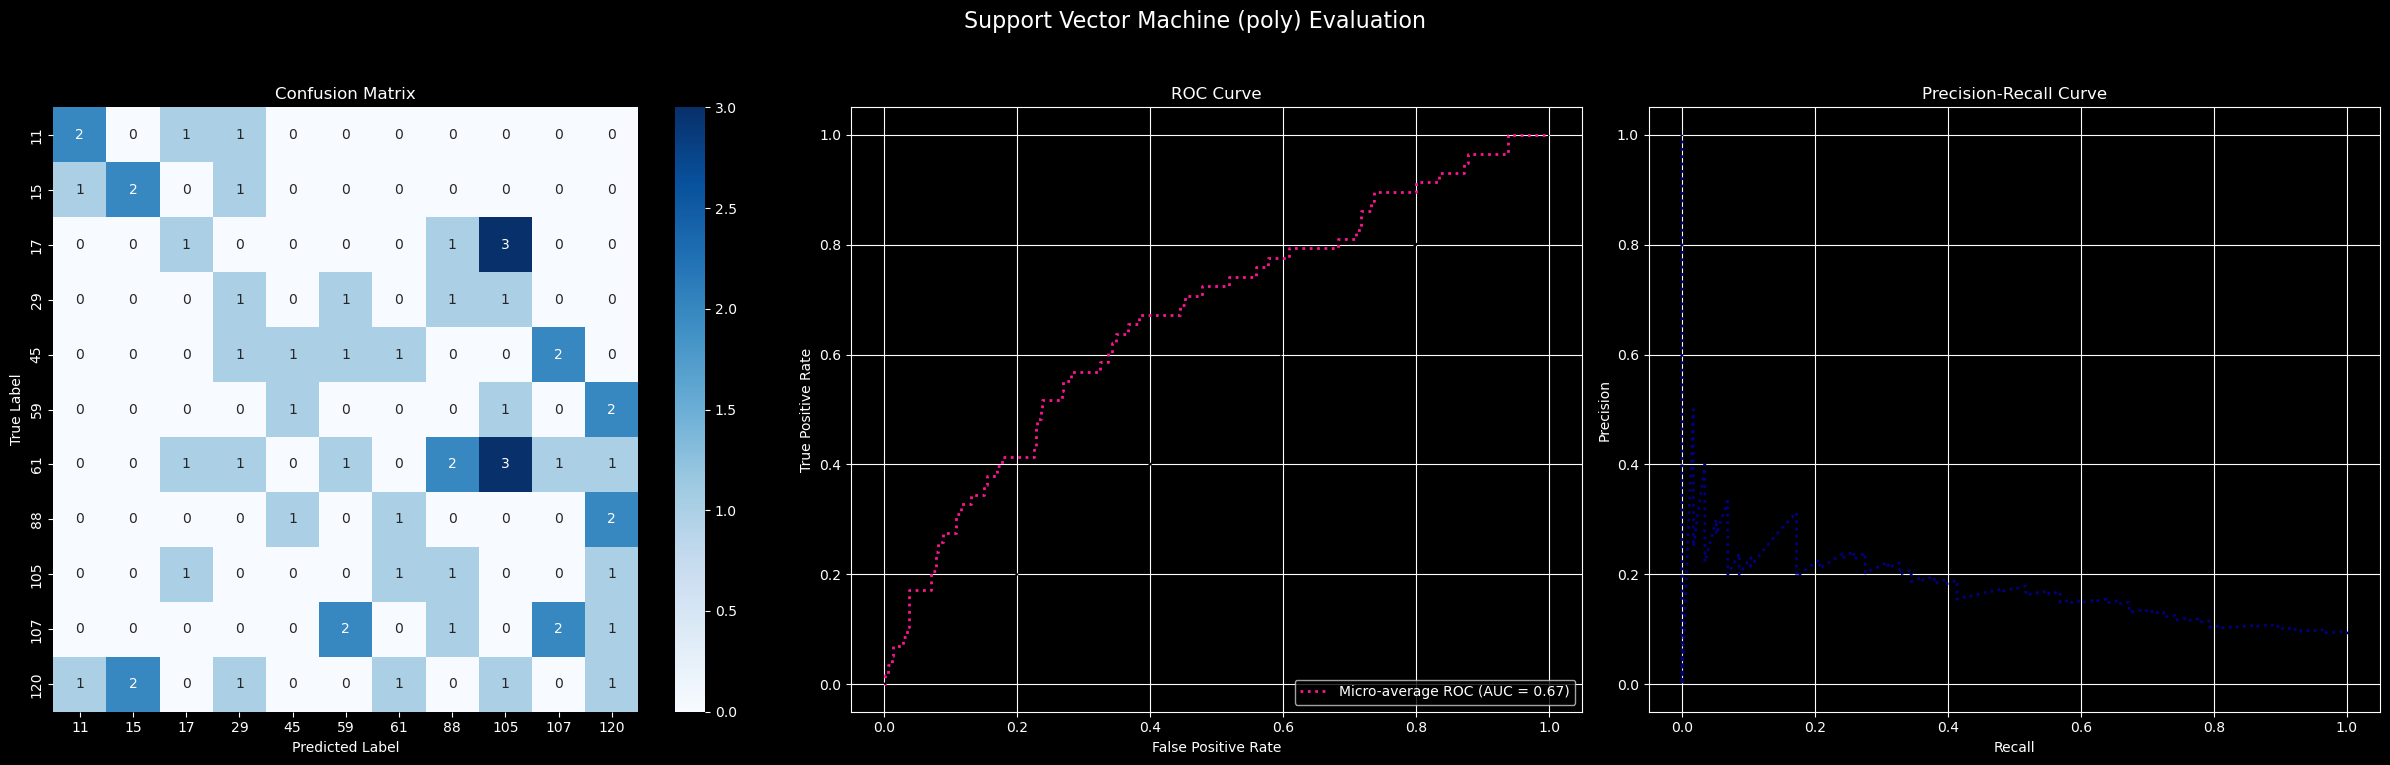


==================== Evaluating Support Vector Machine (rbf) ====================
Accuracy: 0.3276
Weighted Precision: 0.3890
Weighted Recall: 0.3276
Weighted F1-score: 0.3268



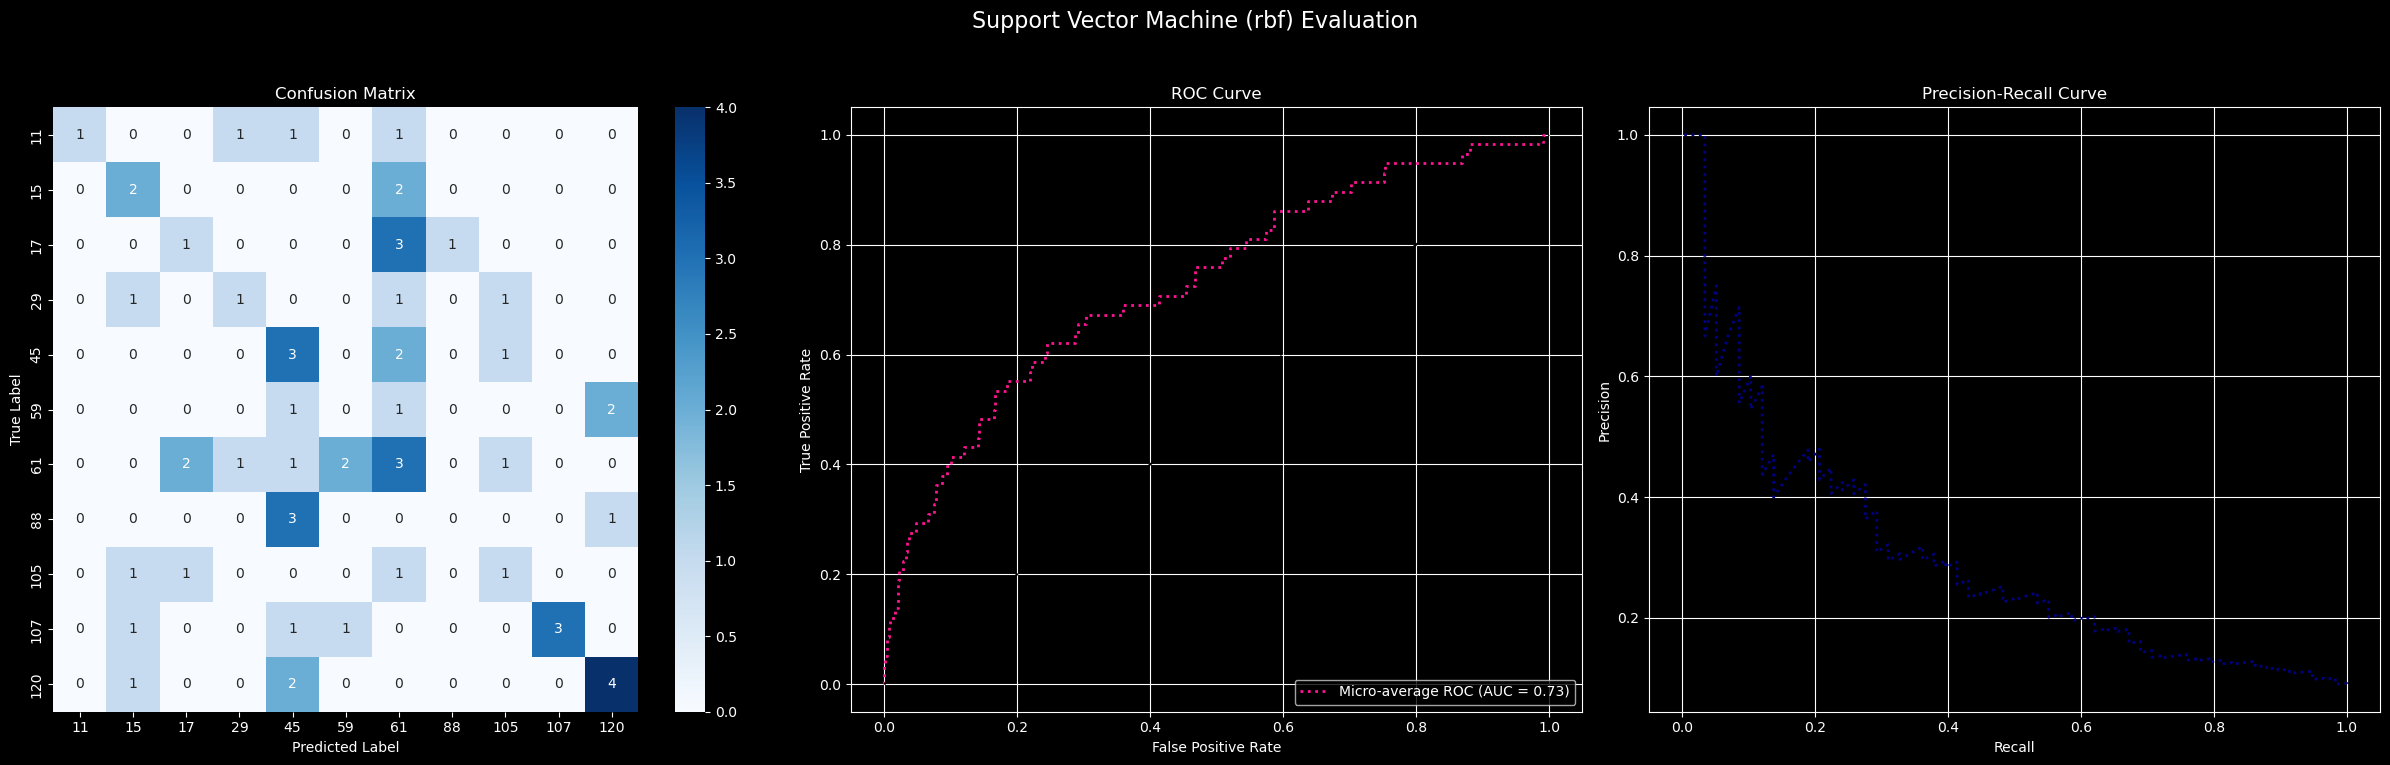


==================== Evaluating Support Vector Machine (sigmoid) ====================
Accuracy: 0.1034
Weighted Precision: 0.0903
Weighted Recall: 0.1034
Weighted F1-score: 0.0926



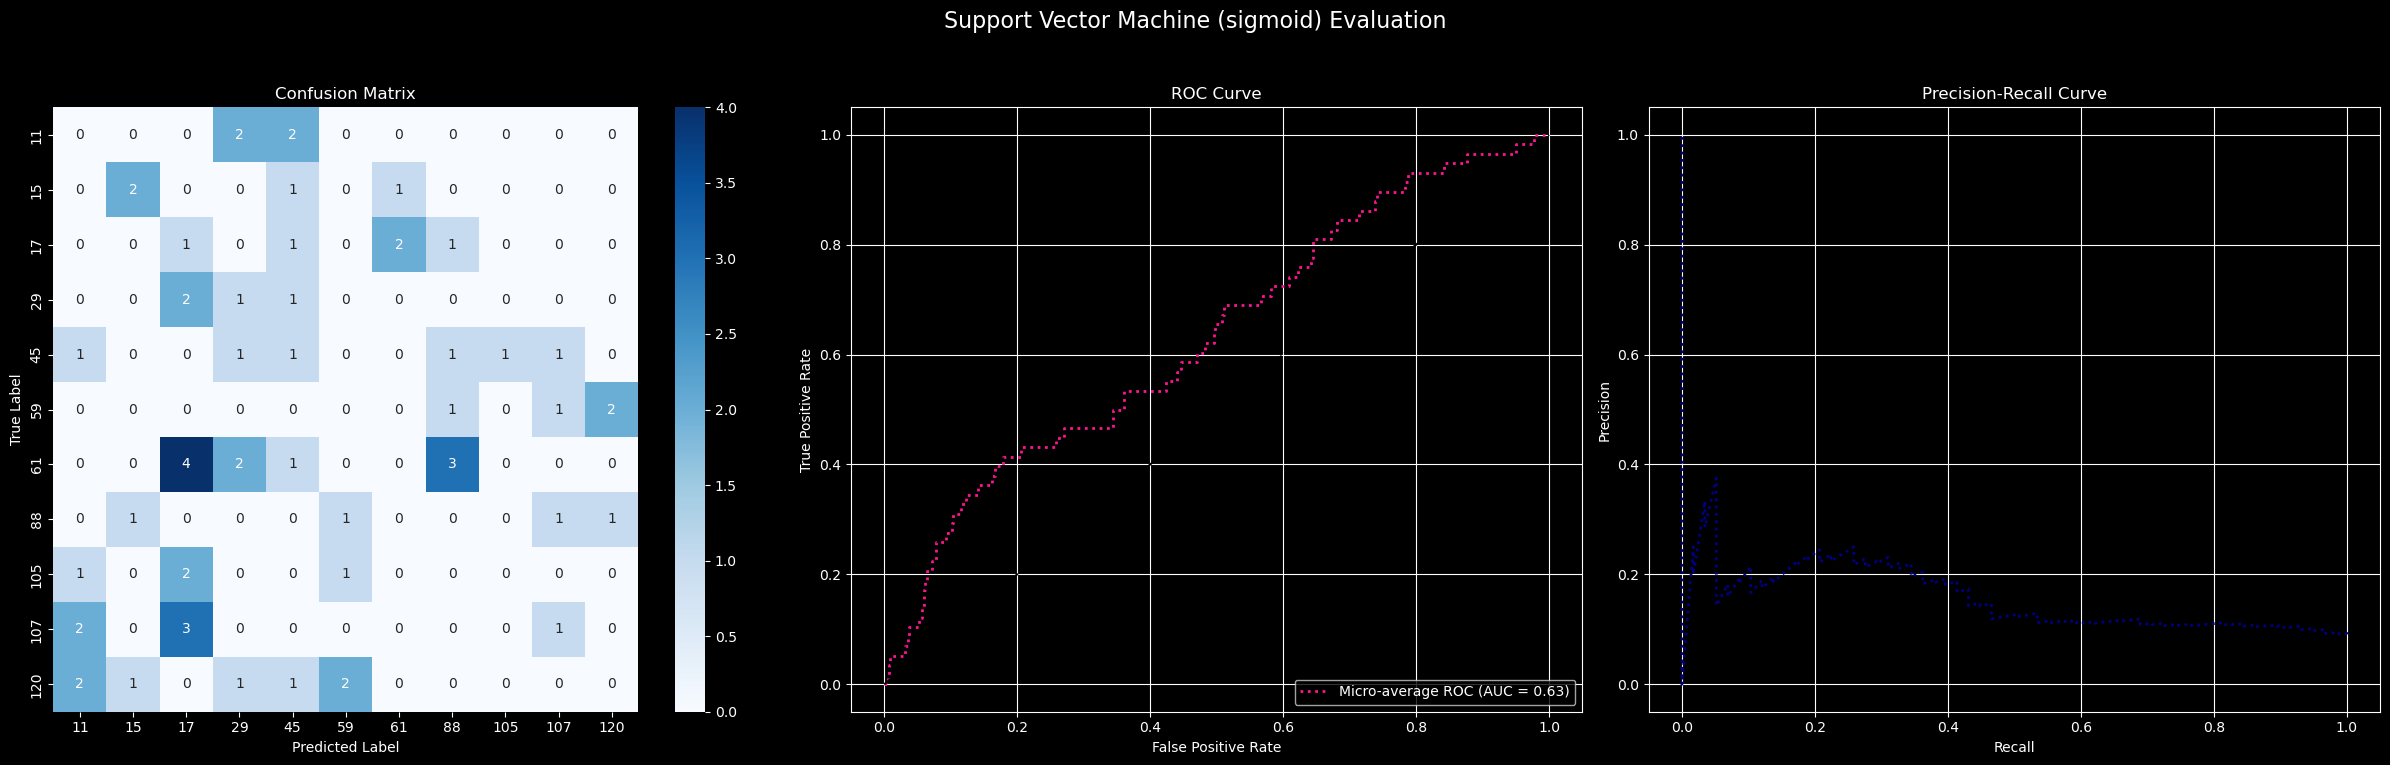

In [55]:
def train_SVM_model(X, y, kernel_list=['linear', 'poly', 'rbf', 'sigmoid']):
    print("--- Training XGBoost Model ---")


    print(f"Using a sample of {X.shape[0]} instances with {len(np.unique(y))} classes.")

    # Split
    X_train, y_train, X_test, y_test, X_val, y_val = split(X, y)

    # Resample
    print("Applying SMOTE to the training data...")    
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # fig_cm, axes_cm = plt.subplots(1, len(kernel_list), figsize=(5 * len(kernel_list), 5))

    for idx, kernel in enumerate(kernel_list):
        model = SVC(kernel=kernel, degree=2, class_weight='balanced', probability=True)

        # Train
        start_train = time.time()
        model.fit(X_train, y_train)

        evaluate_model(model, X_test, y_test, 
               model_name="Support Vector Machine (" + kernel + ")")

train_SVM_model(X_sampled, y_sampled)

### Naive Bayes

--- Training NB Model ---
Using a sample of 289 instances with 11 classes.
Applying SMOTE to the training data...

Training the model...
GNB train time: 0.00s

==================== Evaluating Naive Bayes ====================
Accuracy: 0.2241
Weighted Precision: 0.2155
Weighted Recall: 0.2241
Weighted F1-score: 0.2038



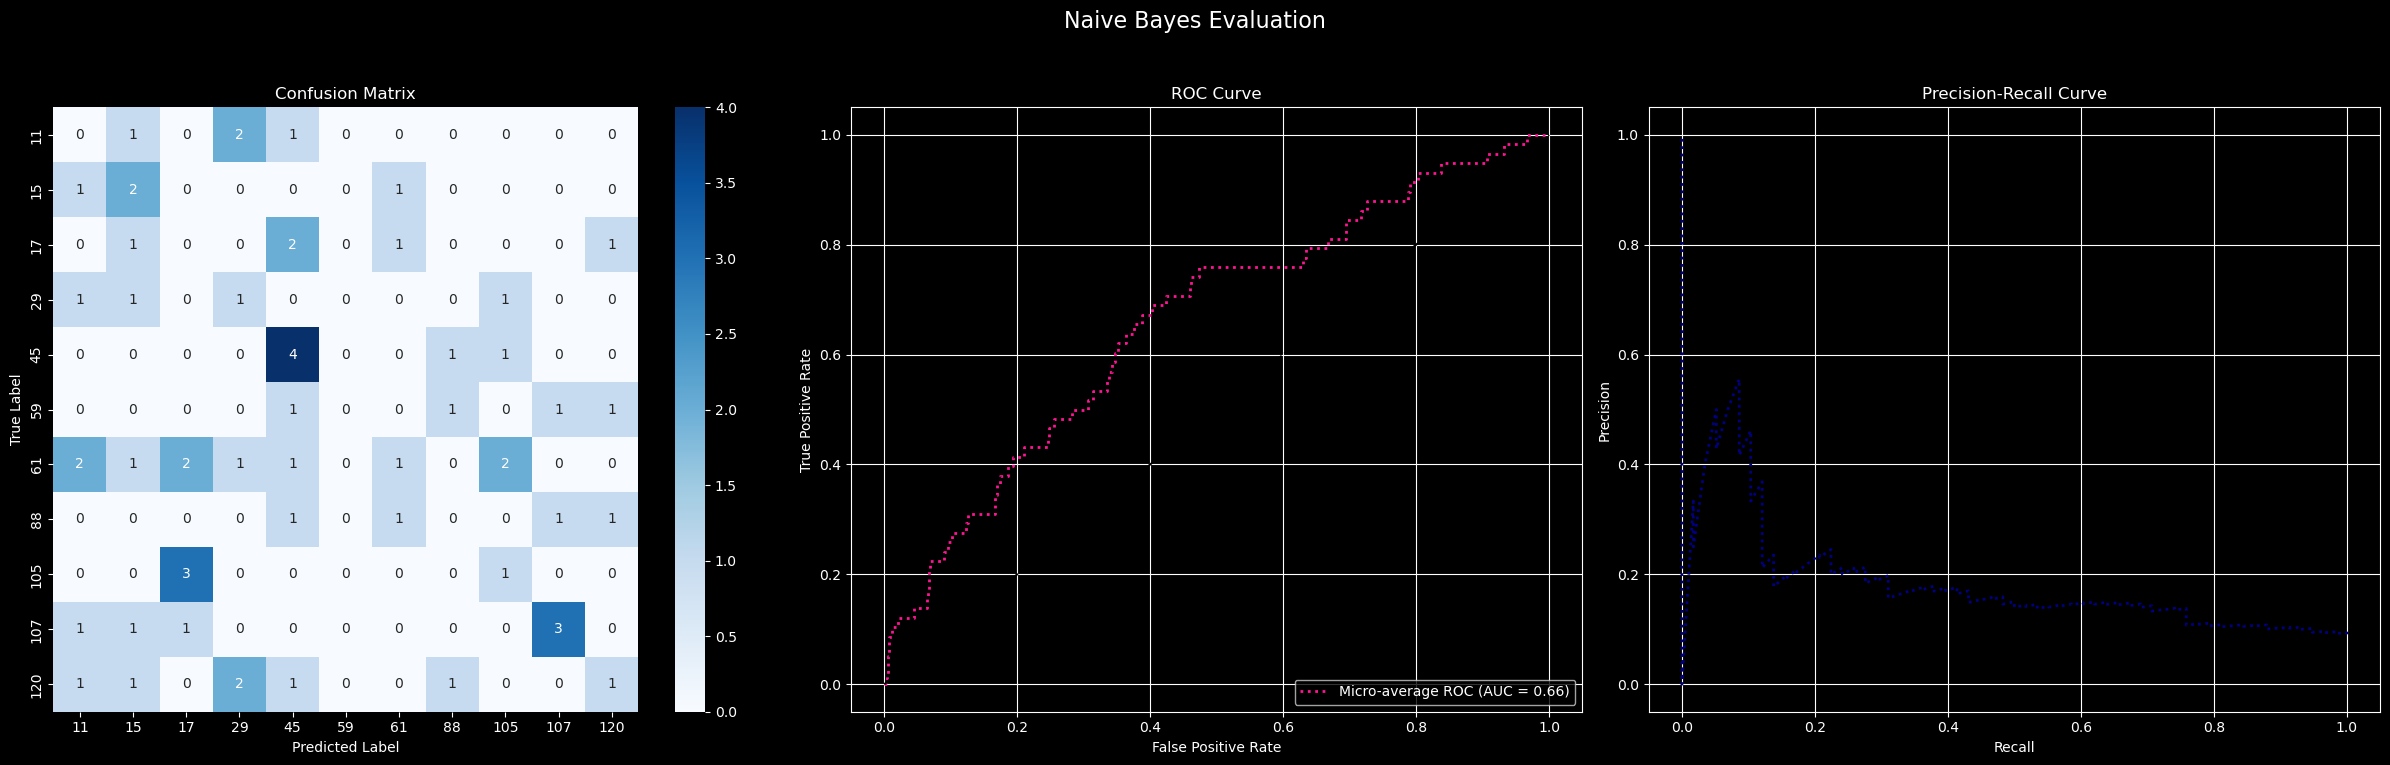

In [56]:
def train_GNB_model(X, y):

    print("--- Training NB Model ---")

    # Sample and clean
    X_sampled, y_sampled = X, y
    print(f"Using a sample of {X_sampled.shape[0]} instances with {len(np.unique(y_sampled))} classes.")

    # Split
    X_train, y_train, X_test, y_test, X_val, y_val = split(X_sampled, y_sampled)

    # Resample
    print("Applying SMOTE to the training data...")
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Train model
    print("\nTraining the model...")
    model = GaussianNB()
    start_train = time.time()
    model.fit(X_train, y_train)
    print(f"GNB train time: {time.time() - start_train:.2f}s")

    # 6. Make predictions and evaluate performance
    evaluate_model(model, X_test, y_test, 
               model_name="Naive Bayes")

train_GNB_model(X_sampled, y_sampled)


### KNN

--- Training KNN Model ---
Using a sample of 289 instances with 11 classes.
Applying SMOTE to the training data...
Training data shape after SMOTE: (407, 20)
KNN train time: 0.00s

==================== Evaluating K Nearest Neighbours ====================
Accuracy: 0.1897
Weighted Precision: 0.2257
Weighted Recall: 0.1897
Weighted F1-score: 0.1843



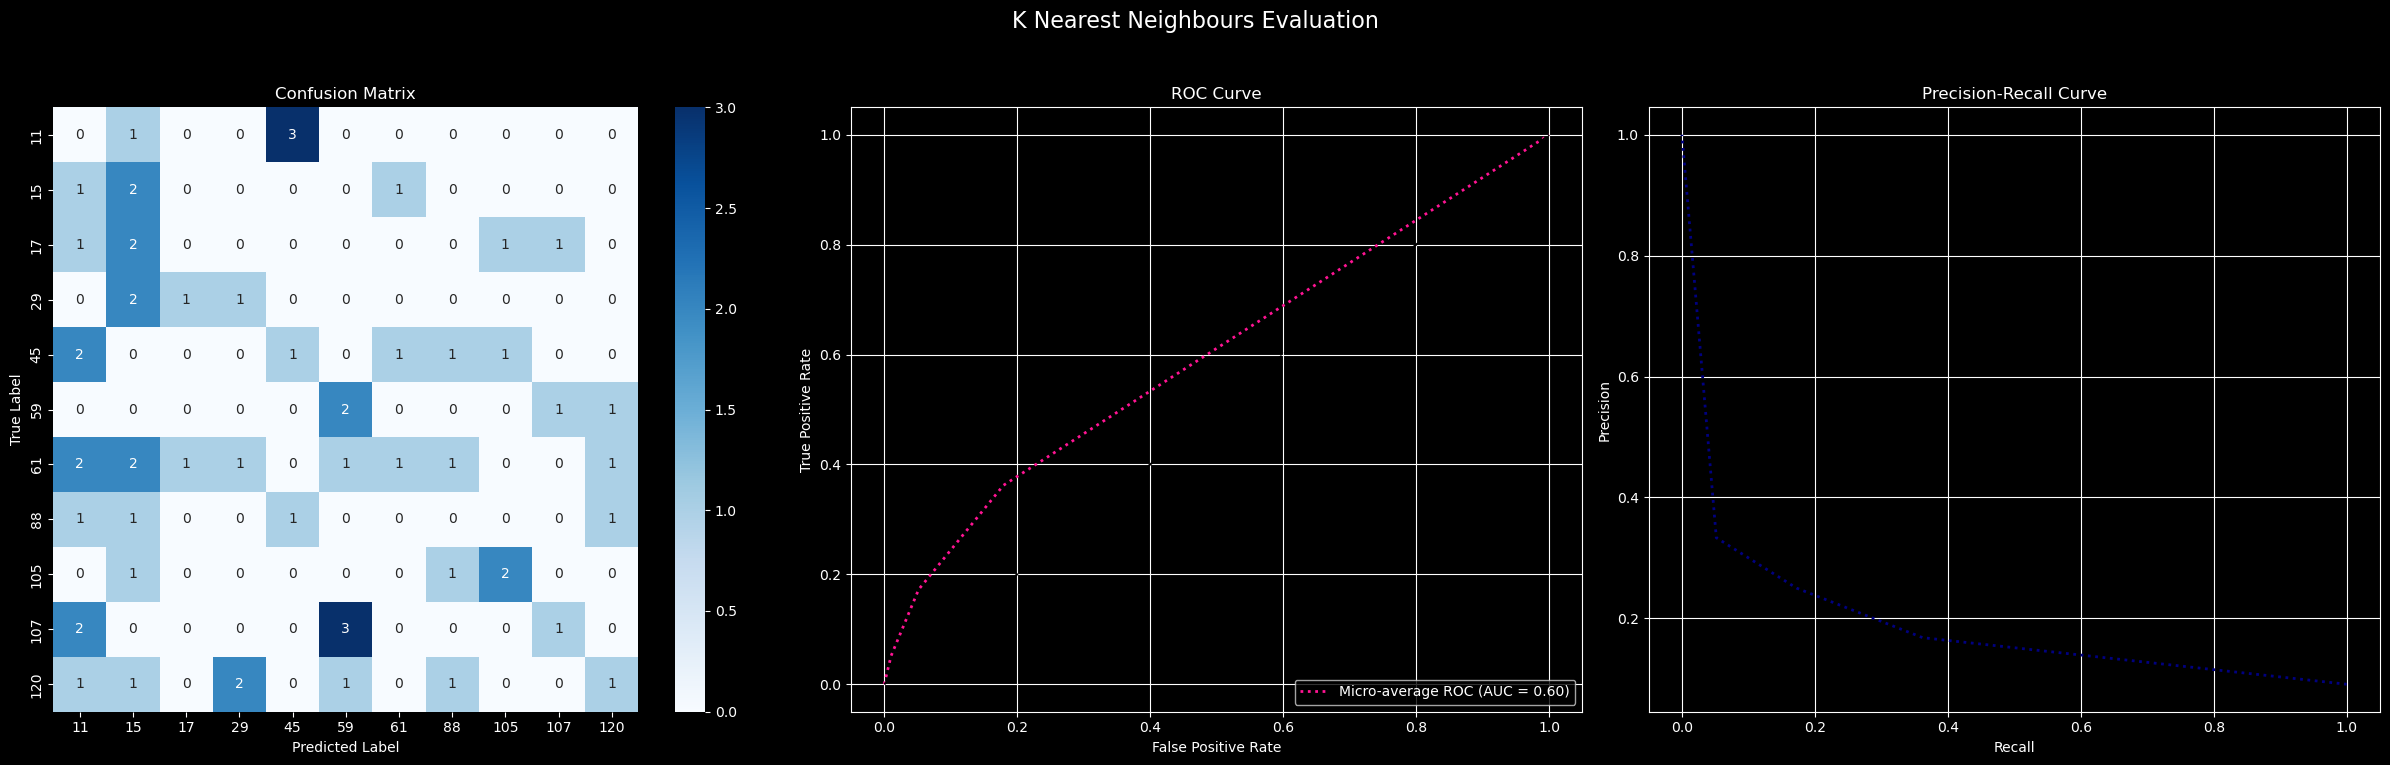

In [57]:
def train_KNN_model(X, y):

    print("--- Training KNN Model ---")

    # Sample and clean
    X_sampled, y_sampled = X, y
    print(f"Using a sample of {X_sampled.shape[0]} instances with {len(np.unique(y_sampled))} classes.")

    # Split
    X_train, y_train, X_test, y_test, X_val, y_val = split(X_sampled, y_sampled)

    # Resample
    print("Applying SMOTE to the training data...")
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"Training data shape after SMOTE: {X_train.shape}")

    # Train model
    model = KNeighborsClassifier(n_neighbors=3, p=1)
    start_train = time.time()
    model.fit(X_train, y_train)
    print(f"KNN train time: {time.time() - start_train:.2f}s")

    # 6. Evaluate the model using our universal function
    evaluate_model(model, X_test, y_test, 
                   model_name="K Nearest Neighbours")

train_KNN_model(X_sampled, y_sampled)

### Random Forest

--- Training XGBoost Model ---
Using a sample of 289 instances with 11 classes.
Training data shape: (231, 20)
Applying SMOTE to the training data...
Training data shape after SMOTE: (407, 20)
Number of classes: 11

Training the model...

==================== Evaluating XGBoost Classifier ====================
Accuracy: 0.2241
Weighted Precision: 0.2279
Weighted Recall: 0.2241
Weighted F1-score: 0.2211



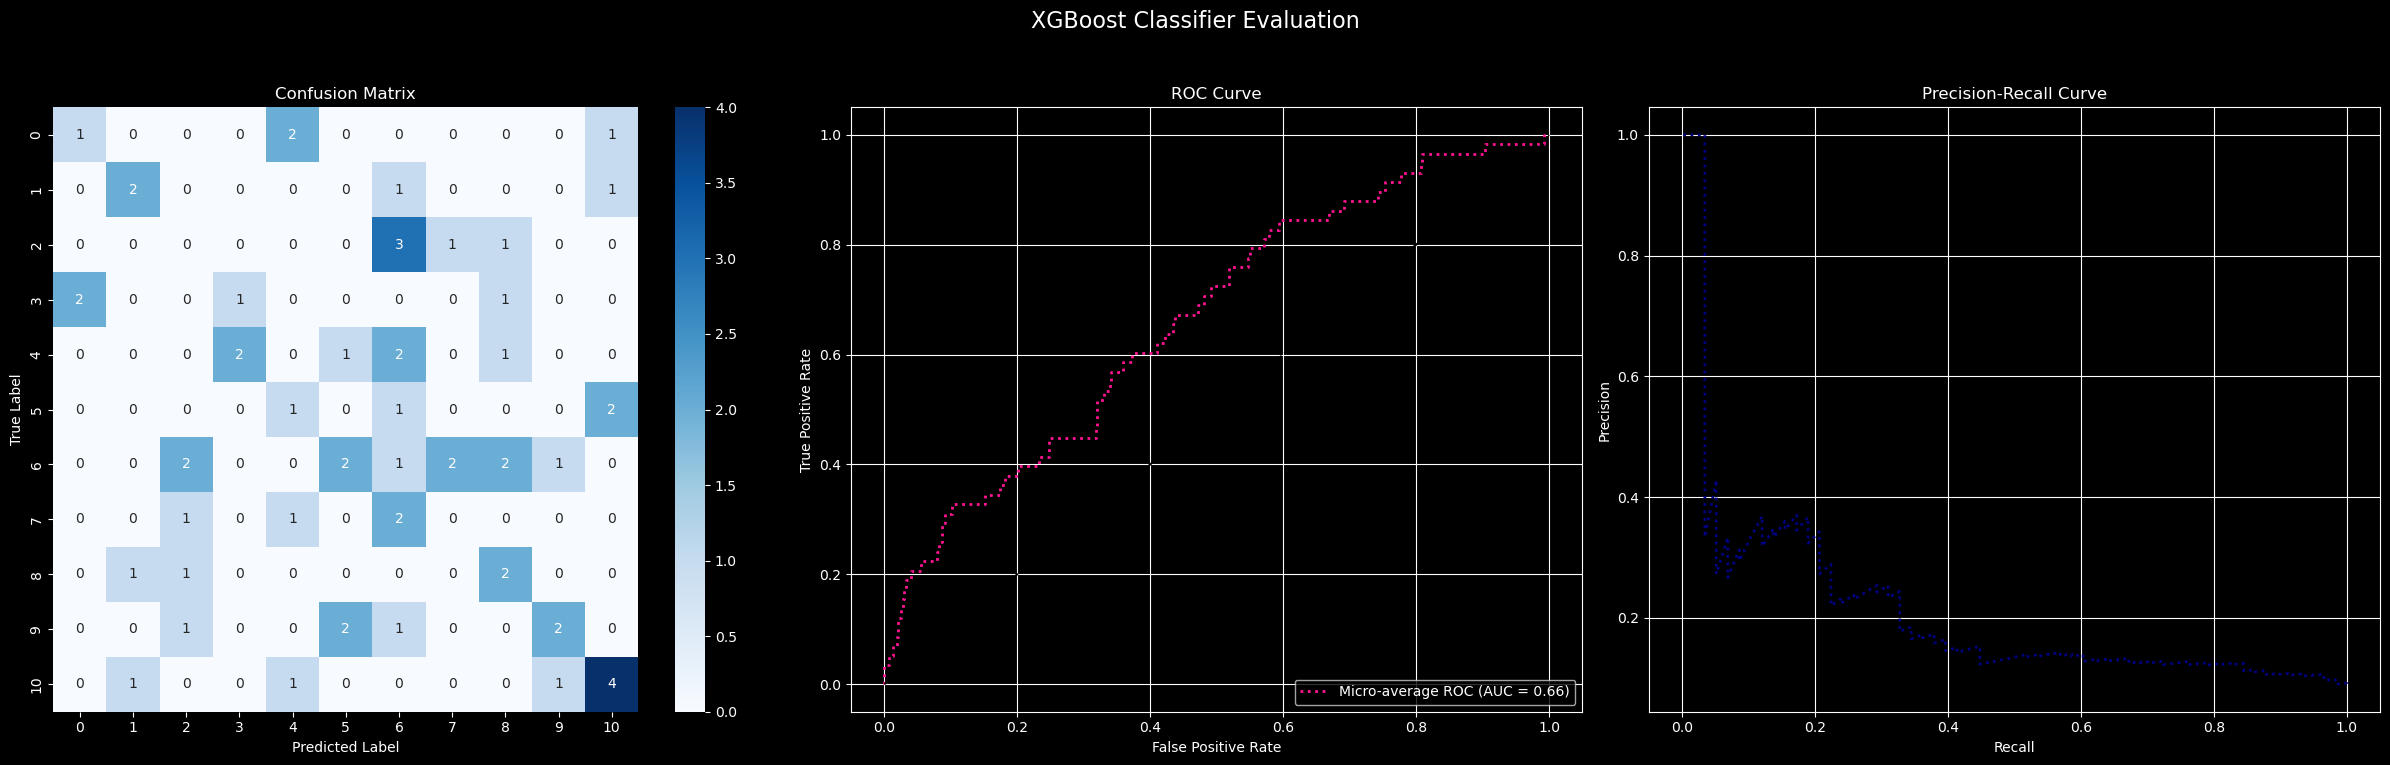


Performing hyperparameter tuning...
Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Best parameters: {'colsample_bytree': 0.6, 'gamma': 0.5, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.6}
Test accuracy: 0.25862068965517243

==================== Evaluating Best XGBoost Classifier ====================
Accuracy: 0.2586
Weighted Precision: 0.2752
Weighted Recall: 0.2586
Weighted F1-score: 0.2612



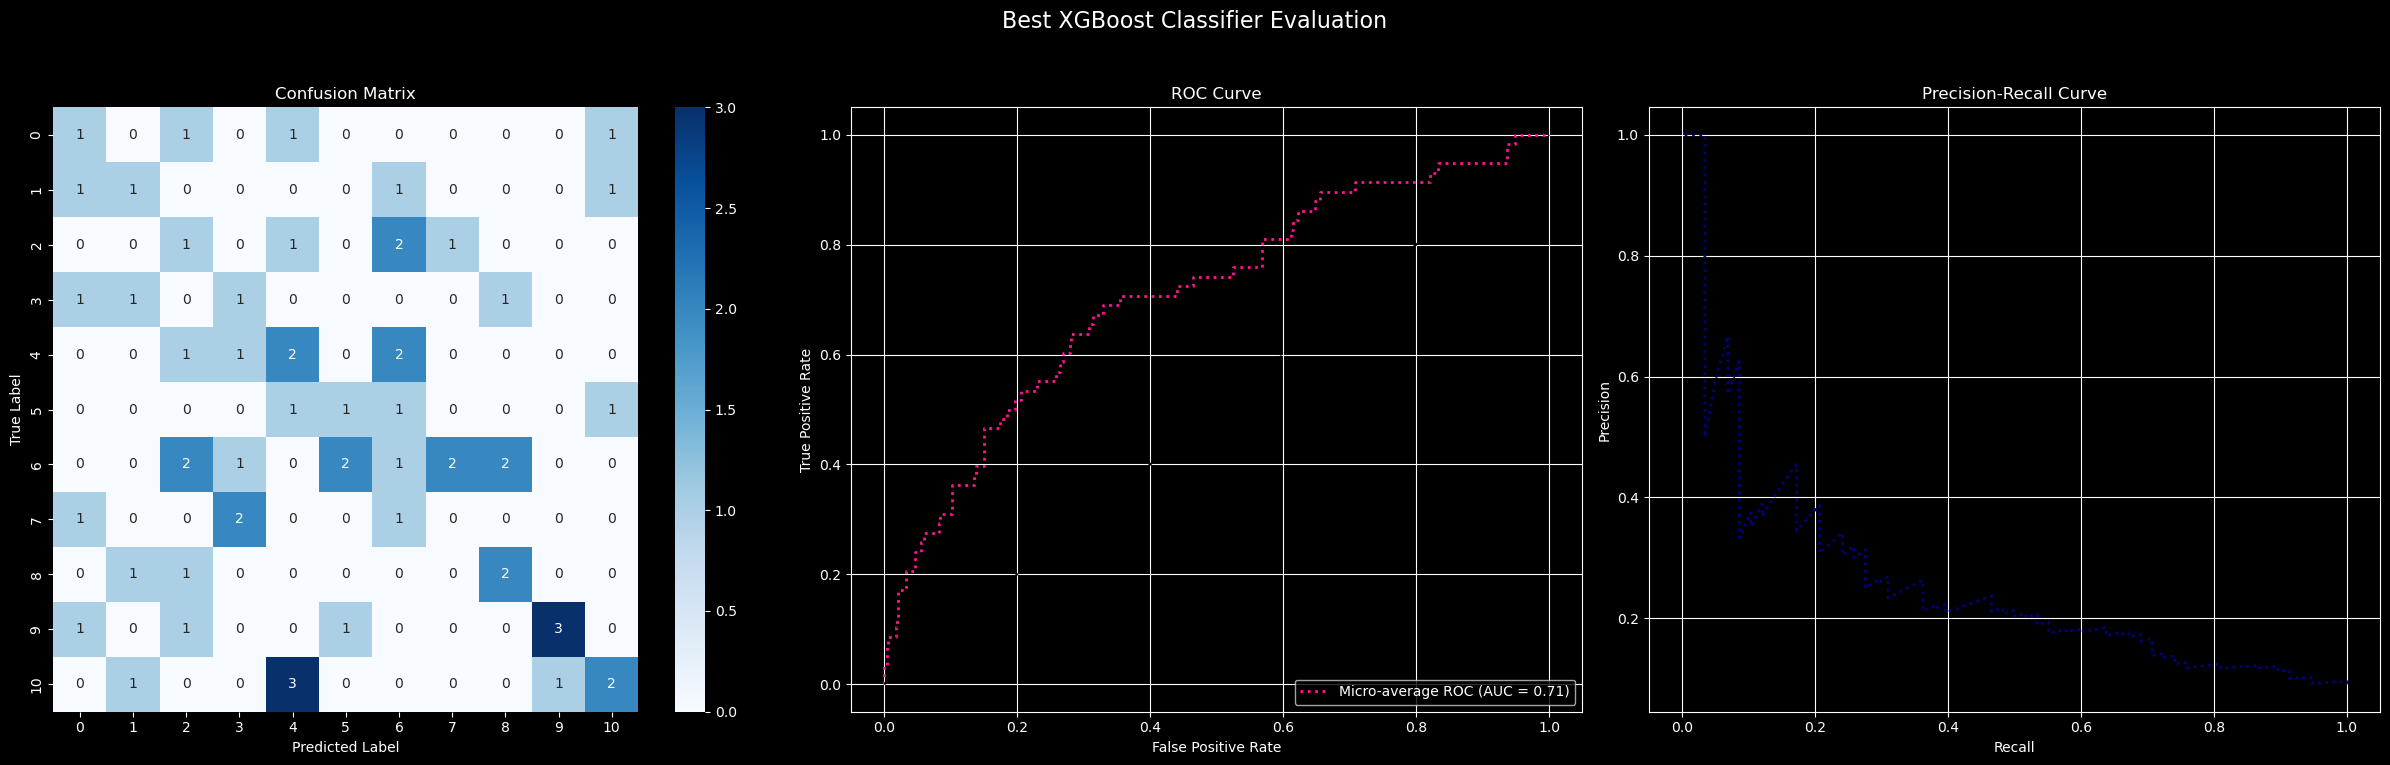

In [58]:


def train_XGB_model(X, y):
    """
    Trains, evaluates, and visualizes a simple XGBoost model,
    """
    print("--- Training XGBoost Model ---")

    #  Sample and clean the data

    print(f"Using a sample of {X.shape[0]} instances with {len(np.unique(y))} classes.")



    local_le = LabelEncoder()
    y_relabled = local_le.fit_transform(y)
    
    
    #  Split data into training and testing sets
    X_train, y_train, X_test, y_test, _, _ = split(X, y_relabled, validation=False)

    print(f"Training data shape: {X_train.shape}")

    # Handle class imbalance
    print("Applying SMOTE to the training data...")
    min_class_count = np.min(np.unique(y_train, return_counts=True)[1])
    k_neighbors = min(2, min_class_count - 1) if min_class_count > 1 else 1
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    n_classes = len(np.unique(y_train))
    print(f"Training data shape after SMOTE: {X_train.shape}")
    print(f"Number of classes: {n_classes}")

    # Define and train the XGBoost model
    model = xgb.XGBClassifier(
        objective="multi:softprob",
        random_state=42,
    )

    print("\nTraining the model...")
    
    
    model.fit(X_train, y_train)
    
    # Make predictions and evaluate performance
    evaluate_model(model, X_test, y_test, model_name="XGBoost Classifier")

    params = {
            'min_child_weight': [1, 5, 10],
            'gamma': [0.5, 1, 1.5, 2, 5],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'max_depth': [3, 4, 5]
    }

    # Perform hyperparameter tuning using GridSearchCV
    print("\nPerforming hyperparameter tuning...")
    grid_search = GridSearchCV(
        model,
        param_grid=params,
        scoring='accuracy',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_
    print("Best parameters:", grid_search.best_params_)

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))

    evaluate_model(best_model, X_test, y_test, model_name="Best XGBoost Classifier")

    

# Run the updated function
train_XGB_model(X_sampled, y_sampled)

### Perceptron

--- Training Perceptron Model ---
Using a sample of 289 instances with 11 classes.
Applying SMOTE to the training data...
Training data shape after SMOTE: (407, 20)

Training the model...
Logistic Regression train time: 0.01s

==================== Evaluating Model ====================
Accuracy: 0.1897
Weighted Precision: 0.1599
Weighted Recall: 0.1897
Weighted F1-score: 0.1666



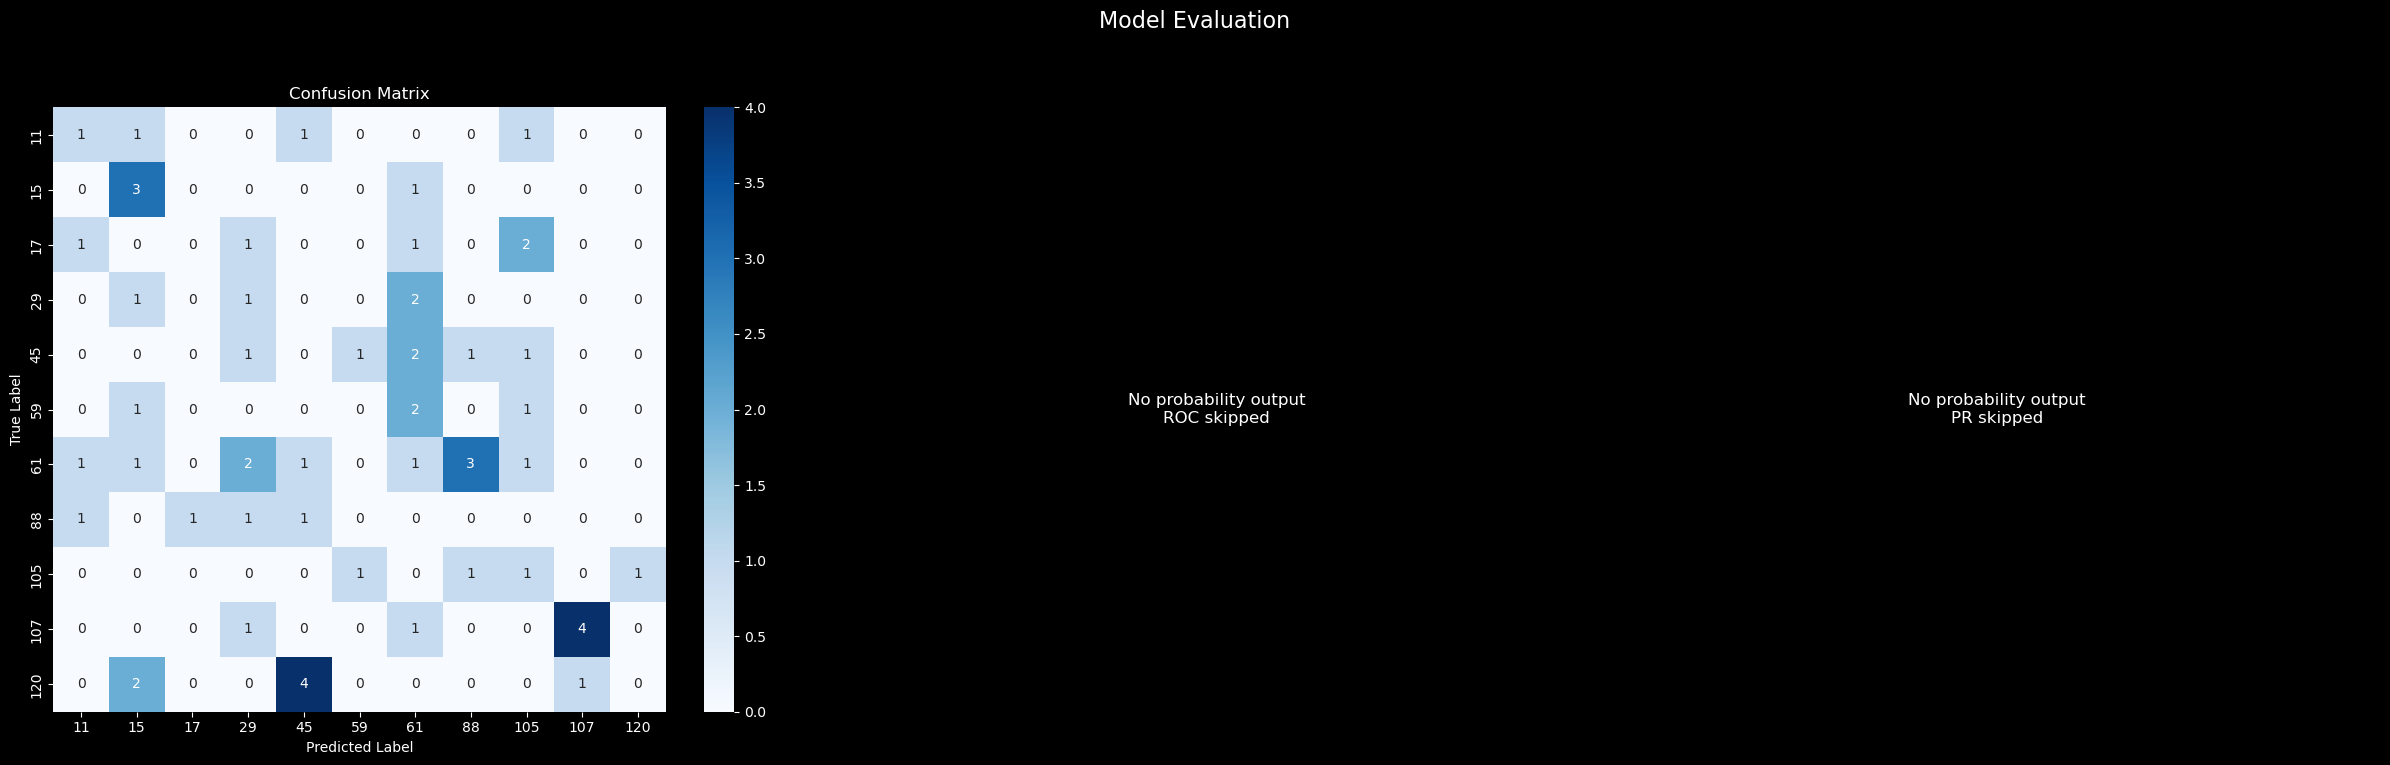

Best parameters: {'alpha': 0.001, 'eta0': 0.1, 'fit_intercept': True, 'max_iter': 500, 'penalty': 'elasticnet'}
Test accuracy: 0.1896551724137931

==================== Evaluating Best Perceptron Classifier ====================
Accuracy: 0.1897
Weighted Precision: 0.1795
Weighted Recall: 0.1897
Weighted F1-score: 0.1774



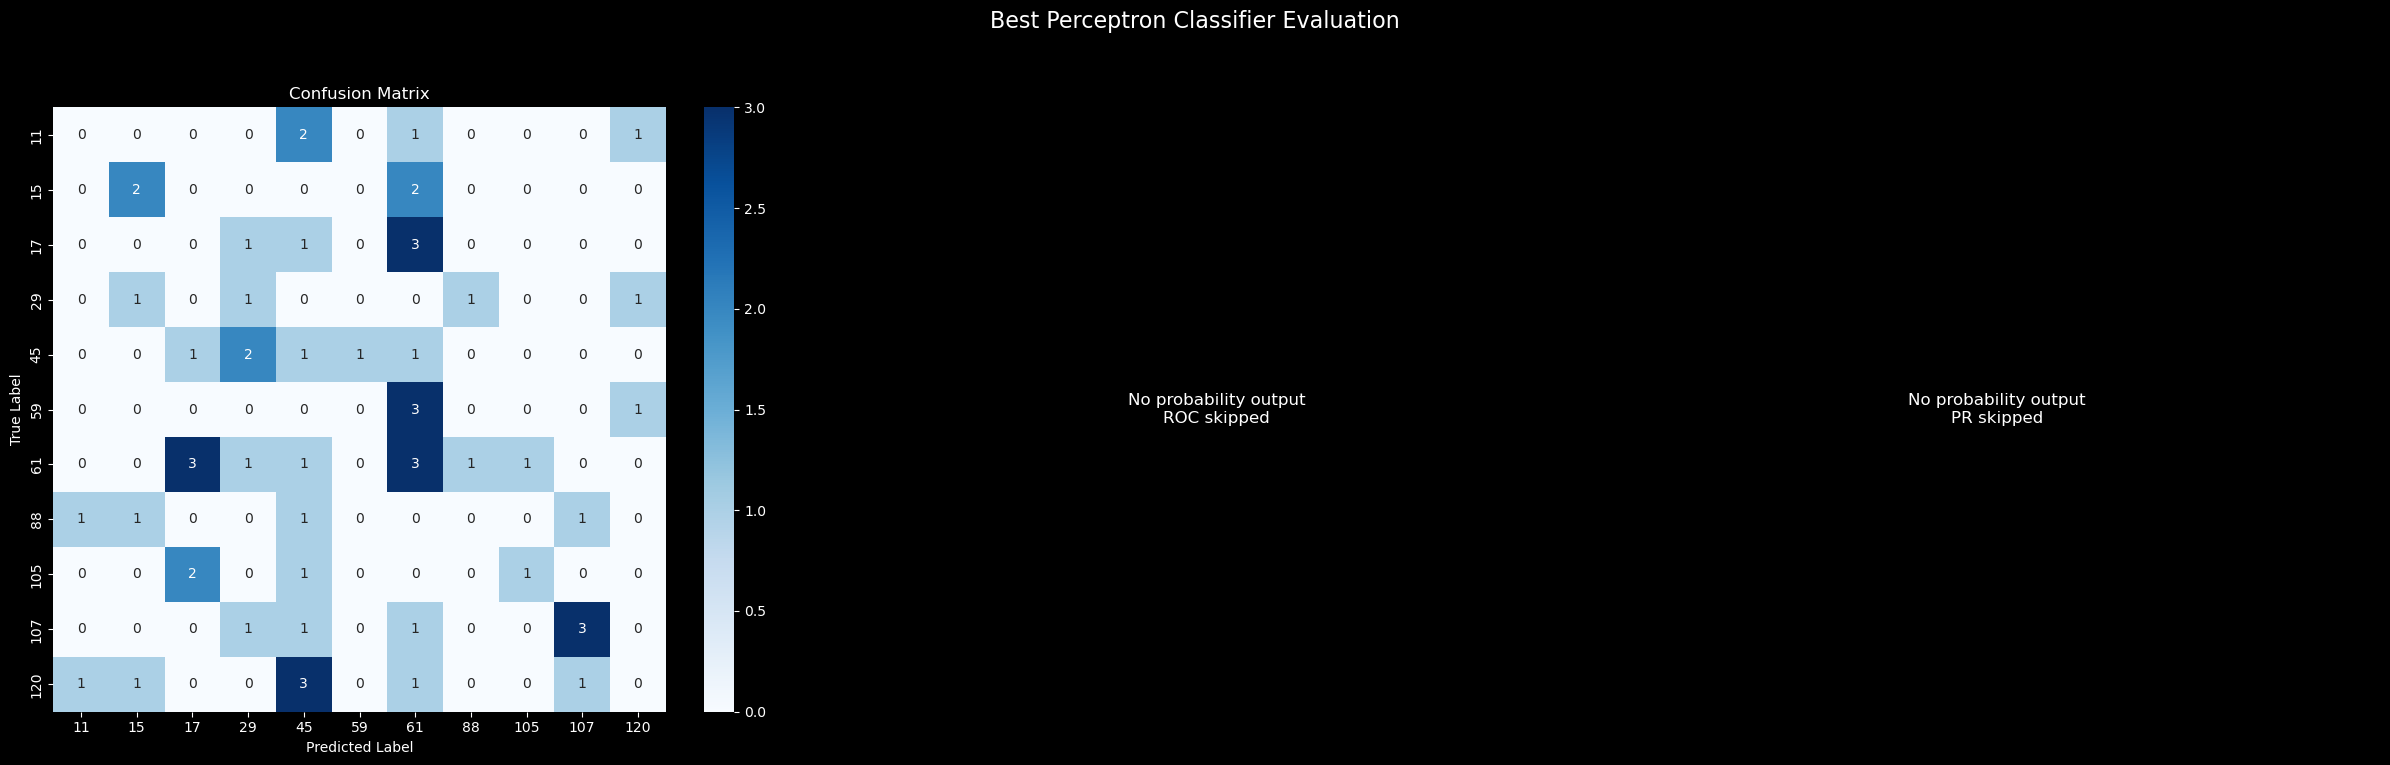

In [59]:
from sklearn.linear_model import  Perceptron

def train_Perceptron_model(X, y):
    """
    Trains, evaluates, and visualizes a Perceptron model.
    """
    print("--- Training Perceptron Model ---")

    # Sample and clean the data
    X_sampled, y_sampled = X, y
    print(f"Using a sample of {X_sampled.shape[0]} instances with {len(np.unique(y_sampled))} classes.")

    
    # Split data into training and testing sets
    X_train, y_train, X_test, y_test, _, _ = split(X_sampled, y_sampled, validation=False)

    # Handle class imbalance
    print("Applying SMOTE to the training data...")
    min_class_count = np.min(np.unique(y_train, return_counts=True)[1])
    k_neighbors = min(2, min_class_count - 1) if min_class_count > 1 else 1
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    

    print(f"Training data shape after SMOTE: {X_train.shape}")


    # 5. Define and train the Logistic Regression model
    model = Perceptron(random_state=42)

    print("\nTraining the model...")
    start_train = time.time()
    model.fit(X_train, y_train)
    print(f"Logistic Regression train time: {time.time() - start_train:.2f}s")

    # 6. Evaluate the model using our universal function
    evaluate_model(model, X_test, y_test)

    # find best model parameters using GridSearchCV

    param_grid = {
        'penalty': ['l2', 'l1', 'elasticnet', None],
        'alpha': [0.0001, 0.001, 0.01],
        'eta0': [0.1, 1.0, 10.0],
        'max_iter': [500, 1000, 2000],
        'fit_intercept': [True, False]
    }


    perceptron = Perceptron(random_state=42)

    grid_search = GridSearchCV(perceptron, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_
    print("Best parameters:", grid_search.best_params_)

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    evaluate_model(best_model, X_test, y_test, model_name="Best Perceptron Classifier")

    

# Run the new function
train_Perceptron_model(X_sampled, y_sampled)

so we see the perceptron is not realy adequate for such a complex task

Sources:
- https://www.kaggle.com/code/jocelyndumlao/birdclef-2025-mfcc-feature-roc-auc-analysis#Import-Libraries (24.05.2025)
- https://github.com/UtrechtUniversity/animal-sounds (24.05.2025)
- https://www.kaggle.com/competitions/birdclef-2025/discussion/572928 (24.05.2025)
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html (23.06.2025)